## Imports

In [1]:
import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [2]:
sns.set_theme(style="ticks", context="notebook")

## Load .dil file

In [3]:
file_name = "demo/Third_test.dil"

g = globals()
with open(file_name, "rb") as file:
    list_of_variable_names = dill.load(file)
    for variable_name in list_of_variable_names:
        g[variable_name] = dill.load(file)

print("variables that have been loaded:")
print(list_of_variable_names)

variables that have been loaded:
('lps', 'posterior_samples_mu_a', 'posterior_samples_sigma_a', 'posterior_samples_mu_sigmasq', 'posterior_samples_beta_sigmasq', 'posterior_samples_mu_w', 'posterior_samples_sigma_w', 'posterior_samples_sigma_mu_x', 'posterior_samples_mu_x', 'posterior_samples_a', 'posterior_samples_sigmasq', 'posterior_samples_w', 'posterior_samples_states', 'num_trials', 'num_inputs', 'num_trials_per_subject', 'num_subjects', 'num_iters', 'inputs', 'emissions', 'masks')


In [4]:
per = pd.read_csv("Data/PerceptualTaskData.csv")
per["IDcode"] = pd.to_numeric(per["IDcode"], errors="coerce").astype("Int64")

sym = pd.read_csv("Data/SymptomData.csv")
sym["IDcode"] = pd.to_numeric(sym["IDcode"], errors="coerce")

print(sym.columns.tolist())
sym.head()

print("posterior_samples_a shape:", posterior_samples_a.shape)
print("posterior_samples_sigmasq shape:", posterior_samples_sigmasq.shape)
print(per.shape)
print(per.columns.tolist())

['IDcode', 'Age', 'Sex', 'AnxiousDepression', 'Compulsivity', 'SocialWithdrawal']
posterior_samples_a shape: (4, 5000, 344)
posterior_samples_sigmasq shape: (4, 5000, 344)
(155088, 7)
['IDcode', 'Age', 'Sex', 'Trial', 'Response', 'Stimulus', 'Confidence']


In [5]:
keep_ids = [
    1109430,1136398,1161576,990377,988880,989613,989614,989638,990171,990502,
    1019534,1019545,1019829,1020003,1020094,1026298,1031230,1056155,1076128,
    1076202,1076245,1076467,1077091,1077672,1077748,1083215,1085767,1086215,
    1086429,1086524,1086722,1087676,1087803,1089279,1089330,1089829,1092255,
    1092315,1096800,1097476,1098724,1098967,1099520,1101067,1107685,1107856,
    1109466,1111115,1112029,1112249,1113314,1114743,1114859,944548,953958,
    954010,954564,957126,957158,958563,958619,959561,961534,965512,966909,
    967485,967866,969340,972471,974295,980324,984514,985216,988163,991011,
    998453,1029483,1029603,1029776,1029858,1030062,1030377,1030394,1030711,
    1031236,1032579,1060694,1071048,1072306,954995,955009,955021,955023,
    955077,955083,955102,955119,955240,955276,955303,955342,955383,955683,
    955984,956021,956352,956553,956843,956927,956993,957089,957167,957953,
    958100,958257,958360,958541,958577,958771,959130,959386,959708,960758,
    960817,961191,961560,961864,963283,964156,966004,966051,967144,967215,
    968578,968792,969242,969364,970091,970214,971440,971577,972235,972410,
    972412,972585,972608,972740,973276,973356,973496,973708,973896,974187,
    975356,977249,977374,978290,979523,979791,981984,982296,982316,982404,
    984377,990840,992115,992526,1000003,1002300,1003011,1005185,1055457,
    1055828,1056146,1056537,1057764,1057805,1058277,1058510,1058926,1059194,
    1059249,1059261,1059408,1059911,1060742,1063610,1067860,1069381,1069895,
    1069986,1071196,1071224,1071343,1072006,1072034,1072153,1072208,1074018,
    1074043,1074460,1076254,1077140,1077499,1077520,1077746,1079257,1080555,
    1080861,1081810,1083775,1084292,1084496,1085727,1086436,1087954,1088055,
    1089319,1089331,1089431,1089461,1094362,1094757,1099082,1099754,1100590,
    1102002,1105080,1105574,1106651,1107155,1113140,1113399,1117048,1123812,
    1139756,1164558,982442,982693,983044,983545,983866,983911,984204,984214,
    984218,984230,984337,984798,985205,985936,987475,1005286,1025813,1025854,
    1027427,1028174,1033318,1033745,1039326,1040390,1060306,1066153,1080350,
    1094893,970018,971334,971779,972231,972352,972382,972433,972550,973225,
    973843,974106,974217,974241,974337,974406,974604,974795,975381,975696,
    976140,976152,976614,976932,984212,985153,989292,992393,1000944,1003223,
    1003328,1008892,1008967,1009029,1052583,1059466,1060303,1060654,1061755,
    1066043,1066212,1066462,1066559,1066606,1066734,1068331,1068985,966047,
    969684,969744,969855,970770,973065,973458,1026348,1030251,1030362,1030403,
    1030520,1030648,1031514,1031608,1031873,1032457,1032513,1032530,1032639,
    1033030,1033395,1033397,1033887,1039513,1039632,1039920,1040014,1041483,
    1047104,1054199,1056861,1069540
]

keep_ids = set(keep_ids)

In [6]:
per = per[per["IDcode"].isin(keep_ids)].copy()

data = per.rename(columns={
    "IDcode": "subj",
    "Response": "resp",
    "Stimulus": "evidence",
    "Trial": "trial"
}).copy()

data = data[data["evidence"] != 0].copy()
data["resp"] = data["resp"].astype(int)
data = data.sort_values(["subj", "trial"]).copy()

subj_ids = np.sort(data["subj"].unique())

print("subj_ids shape:", subj_ids.shape)
print("first 10 subj_ids:", subj_ids[:10])
print("number of unique subj_ids:", len(subj_ids))
print("num_subjects from .dil:", num_subjects)


subj_ids shape: (344,)
first 10 subj_ids: [944548 953958 954010 954564 954995 955009 955021 955023 955077 955083]
number of unique subj_ids: 344
num_subjects from .dil: 344


In [7]:
burn_in = 500

post_a = posterior_samples_a[:, burn_in:, :]
post_a = np.array(post_a).reshape(-1, posterior_samples_a.shape[-1])
a_mean = np.mean(post_a, axis=0)

post_sigmasq = posterior_samples_sigmasq[:, burn_in:, :]
post_sigmasq = np.array(post_sigmasq).reshape(-1, posterior_samples_sigmasq.shape[-1])
sigmasq_mean = np.mean(post_sigmasq, axis=0)

hmfc_df = pd.DataFrame({
    "IDcode": subj_ids.astype(int),
    "a": a_mean,
    "sigmasq": sigmasq_mean
})

hmfc_df.head()

,IDcode,a,sigmasq
0,944548,0.865140,0.089516
1,953958,0.904186,0.120482
2,954010,0.874361,0.087816
3,954564,0.896750,0.098646
4,954995,0.911385,0.133151


In [9]:
sym_participant = (
    sym.groupby("IDcode", as_index=False)[
        ["Age", "Sex", "AnxiousDepression", "Compulsivity", "SocialWithdrawal"]
    ]
    .first()
)

print(sym_participant.shape)
print(sym_participant.head())
print("Unique IDs in symptom data:", sym_participant["IDcode"].nunique())

(1098, 6)
   IDcode  Age  Sex  AnxiousDepression  Compulsivity  SocialWithdrawal
0  944548   21    0          -0.293255     -0.621615         -0.032964
1  953958   21    0          -0.566733     -0.123265          0.518405
2  954010   22    0           1.802008      1.126410         -0.098002
3  954564   20    0          -0.528183      0.330763         -0.704537
4  954995   21    0          -0.724605     -0.504122          0.172939
Unique IDs in symptom data: 1098


## Merge symptomdata with hMFC results

In [10]:
df = hmfc_df.merge(sym_participant, on="IDcode", how="inner")

print("Merged dataframe shape:", df.shape)
print("Unique participants in merged df:", df["IDcode"].nunique())
df.head()

Merged dataframe shape: (344, 8)
Unique participants in merged df: 344


,IDcode,a,sigmasq,Age,Sex,AnxiousDepression,Compulsivity,SocialWithdrawal
0,944548,0.865140,0.089516,21,0,-0.293255,-0.621615,-0.032964
1,953958,0.904186,0.120482,21,0,-0.566733,-0.123265,0.518405
2,954010,0.874361,0.087816,22,0,1.802008,1.126410,-0.098002
3,954564,0.896750,0.098646,20,0,-0.528183,0.330763,-0.704537
4,954995,0.911385,0.133151,21,0,-0.724605,-0.504122,0.172939


## log-transform sigmasq (probably better for regression)

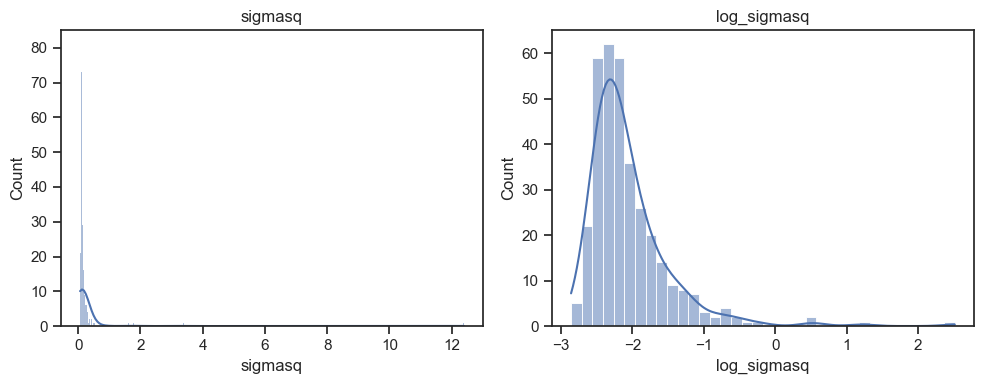

In [11]:
df["log_sigmasq"] = np.log(df["sigmasq"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df["sigmasq"], kde=True, ax=axes[0])
axes[0].set_title("sigmasq")

sns.histplot(df["log_sigmasq"], kde=True, ax=axes[1])
axes[1].set_title("log_sigmasq")

plt.tight_layout()
plt.show()

## Naive tertile approach

In [12]:
df_tert = df.copy()

df_tert["AD_tertile"] = pd.qcut(df_tert["AnxiousDepression"], 3, labels=["low","mid","high"])
df_tert["CIT_tertile"] = pd.qcut(df_tert["Compulsivity"], 3, labels=["low","mid","high"])
df_tert["SW_tertile"] = pd.qcut(df_tert["SocialWithdrawal"], 3, labels=["low","mid","high"])

In [13]:
summary = df_tert.groupby("CIT_tertile")[["a","log_sigmasq"]].agg(["mean","sem"])
summary

/var/folders/4y/sm89msfj70b1mnhdgv9yqnfr0000gn/T/ipykernel_12600/2944765666.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_tert.groupby("CIT_tertile")[["a","log_sigmasq"]].agg(["mean","sem"])


a           log_sigmasq          
                 mean       sem        mean       sem
CIT_tertile                                          
low          0.885827  0.001721   -2.088926  0.041601
mid          0.885037  0.002074   -1.964901  0.066574
high         0.882489  0.002039   -2.119029  0.050997

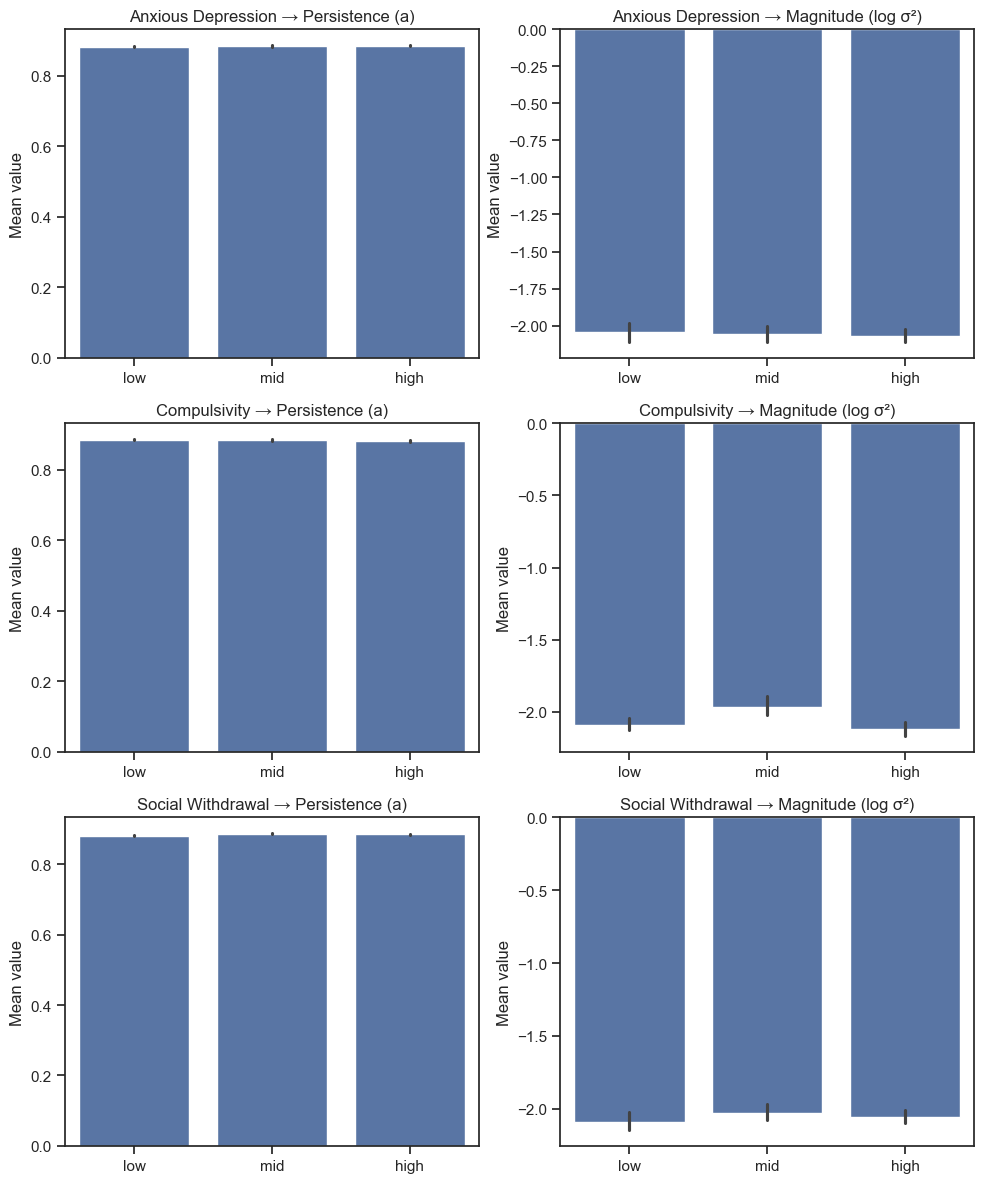

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

dimensions = [
    ("AD_tertile", "Anxious Depression"),
    ("CIT_tertile", "Compulsivity"),
    ("SW_tertile", "Social Withdrawal")
]

for i, (tert, label) in enumerate(dimensions):

    sns.barplot(
        data=df_tert,
        x=tert,
        y="a",
        order=["low", "mid", "high"],
        errorbar=("ci", 68),
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{label} → Persistence (a)")
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("Mean value")

    sns.barplot(
        data=df_tert,
        x=tert,
        y="log_sigmasq",
        order=["low", "mid", "high"],
        errorbar=("ci", 68),
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{label} → Magnitude (log σ²)")
    axes[i, 1].set_xlabel("")
    axes[i, 1].set_ylabel("Mean value")

plt.tight_layout()
plt.show()

## Regression

In [15]:
df_reg = df.copy()

z_cols = ["Age", "AnxiousDepression", "Compulsivity", "SocialWithdrawal"]
scaler = StandardScaler()
df_reg[[c + "_z" for c in z_cols]] = scaler.fit_transform(df_reg[z_cols])

df_reg.head()

,IDcode,a,sigmasq,Age,Sex,AnxiousDepression,Compulsivity,SocialWithdrawal,log_sigmasq,Age_z,AnxiousDepression_z,Compulsivity_z,SocialWithdrawal_z
0,944548,0.865140,0.089516,21,0,-0.293255,-0.621615,-0.032964,-2.413332,-0.414546,-0.307005,-0.764087,0.045106
1,953958,0.904186,0.120482,21,0,-0.566733,-0.123265,0.518405,-2.116257,-0.414546,-0.601974,-0.222807,0.642997
2,954010,0.874361,0.087816,22,0,1.802008,1.126410,-0.098002,-2.432517,-0.319223,1.952904,1.134520,-0.025419
3,954564,0.896750,0.098646,20,0,-0.528183,0.330763,-0.704537,-2.316219,-0.509869,-0.560394,0.270332,-0.683130
4,954995,0.911385,0.133151,21,0,-0.724605,-0.504122,0.172939,-2.016274,-0.414546,-0.772251,-0.636473,0.268382


In [16]:
df_reg["sex_num"] = pd.to_numeric(df_reg["Sex"], errors="coerce")

In [17]:
def run_regression(df, outcome, predictors, add_age=True, add_sex=True):
    X_cols = predictors.copy()

    if add_age:
        X_cols.append("Age_z")
    if add_sex:
        X_cols.append("sex_num")

    tmp = df[[outcome] + X_cols].dropna().copy()

    X = sm.add_constant(tmp[X_cols])
    y = tmp[outcome]

    model = sm.OLS(y, X).fit()

    print("\n" + "="*60)
    print(f"Outcome: {outcome}")
    print(f"Predictors: {X_cols}")
    print("="*60)
    print(model.summary())

    return model

In [18]:
predictors_all = ["AnxiousDepression_z", "Compulsivity_z", "SocialWithdrawal_z"]

single_models = {}

for pred in predictors_all:
    m_a = run_regression(
        df_reg,
        outcome="a",
        predictors=[pred],
        add_age=True,
        add_sex=True
    )

    m_s = run_regression(
        df_reg,
        outcome="log_sigmasq",
        predictors=[pred],
        add_age=True,
        add_sex=True
    )

    single_models[(pred, "a")] = m_a
    single_models[(pred, "log_sigmasq")] = m_s


Outcome: a
Predictors: ['AnxiousDepression_z', 'Age_z', 'sex_num']
                            OLS Regression Results                            
Dep. Variable:                      a   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9636
Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.410
Time:                        08:59:03   Log-Likelihood:                 844.85
No. Observations:                 344   AIC:                            -1682.
Df Residuals:                     340   BIC:                            -1666.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [19]:
def extract_single_model_results(single_models):
    rows = []

    predictor_label_map = {
        "AnxiousDepression_z": "AD",
        "Compulsivity_z": "CIT",
        "SocialWithdrawal_z": "SW"
    }

    outcome_label_map = {
        "a": "Persistence (a)",
        "log_sigmasq": "Magnitude (log σ²)"
    }

    for (pred, outcome), model in single_models.items():
        conf = model.conf_int()

        rows.append({
            "predictor": predictor_label_map[pred],
            "outcome": outcome_label_map[outcome],
            "beta": model.params[pred],
            "ci_low": conf.loc[pred, 0],
            "ci_high": conf.loc[pred, 1],
            "p": model.pvalues[pred]
        })

    return pd.DataFrame(rows)

single_plot_df = extract_single_model_results(single_models)
single_plot_df

,predictor,outcome,beta,ci_low,ci_high,p
0,AD,Persistence (a),0.001301,-0.000983,0.003585,0.263240
1,AD,Magnitude (log σ²),-0.017981,-0.081597,0.045635,0.578610
2,CIT,Persistence (a),-0.001107,-0.003459,0.001245,0.355150
3,CIT,Magnitude (log σ²),-0.014284,-0.079766,0.051198,0.668147
4,SW,Persistence (a),0.001518,-0.000777,0.003814,0.194040
5,SW,Magnitude (log σ²),0.011201,-0.052789,0.075191,0.730836


In [20]:
def plot_single_models(single_plot_df, title="Single-predictor regression models"):
    predictors = ["AD", "CIT", "SW"]
    outcomes = ["Persistence (a)", "Magnitude (log σ²)"]

    x = np.arange(len(predictors))
    width = 0.32
    offsets = [-width/2, width/2]

    fig, ax = plt.subplots(figsize=(9, 5))

    for i, outcome in enumerate(outcomes):
        sub = single_plot_df[single_plot_df["outcome"] == outcome].copy()
        sub = sub.set_index("predictor").loc[predictors].reset_index()

        betas = sub["beta"].values
        ci_low = sub["ci_low"].values
        ci_high = sub["ci_high"].values

        yerr = np.vstack([
            betas - ci_low,
            ci_high - betas
        ])

        ax.bar(
            x + offsets[i],
            betas,
            width=width,
            yerr=yerr,
            capsize=4,
            label=outcome
        )

        for j, row in sub.iterrows():
            if row["p"] < 0.05:
                star_y = min(row["ci_low"] - 0.03, -0.03)
                ax.text(
                    x[j] + offsets[i],
                    star_y,
                    "*",
                    ha="center",
                    va="top",
                    fontsize=16
                )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(predictors)
    ax.set_ylabel("Regression coefficient")
    ax.set_xlabel("Predictor")
    ax.set_title(title)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()

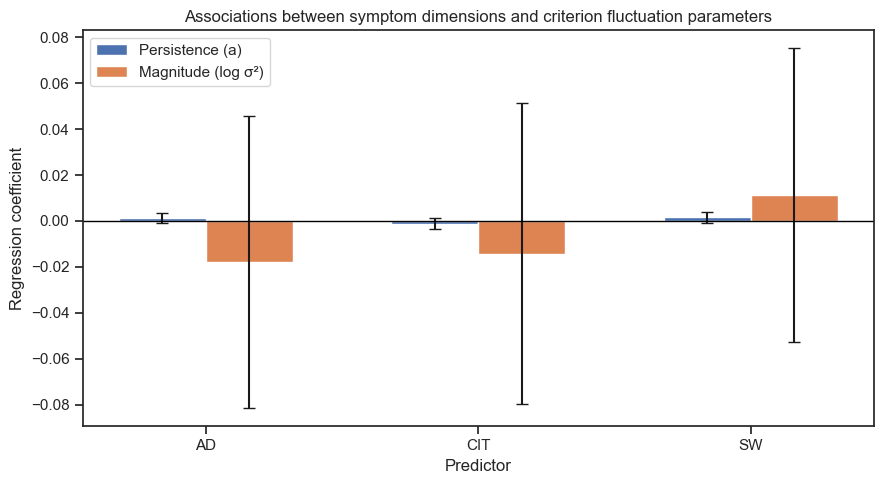

In [21]:
plot_single_models(
    single_plot_df,
    title="Associations between symptom dimensions and criterion fluctuation parameters"
)

## Combined regression

In [22]:
predictors_all = ["AnxiousDepression_z", "Compulsivity_z", "SocialWithdrawal_z"]

model_a_combined = run_regression(
    df_reg,
    outcome="a",
    predictors=predictors_all,
    add_age=True,
    add_sex=True
)

model_s_combined = run_regression(
    df_reg,
    outcome="log_sigmasq",
    predictors=predictors_all,
    add_age=True,
    add_sex=True
)


Outcome: a
Predictors: ['AnxiousDepression_z', 'Compulsivity_z', 'SocialWithdrawal_z', 'Age_z', 'sex_num']
                            OLS Regression Results                            
Dep. Variable:                      a   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.283
Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.271
Time:                        08:59:23   Log-Likelihood:                 846.62
No. Observations:                 344   AIC:                            -1681.
Df Residuals:                     338   BIC:                            -1658.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------

In [23]:
def extract_combined_results(model, outcome):
    
    rows = []
    conf = model.conf_int()
    
    predictors = {
        "AnxiousDepression_z": "AD",
        "Compulsivity_z": "CIT",
        "SocialWithdrawal_z": "SW"
    }
    
    for pred, label in predictors.items():
        
        rows.append({
            "predictor": label,
            "outcome": outcome,
            "beta": model.params[pred],
            "ci_low": conf.loc[pred,0],
            "ci_high": conf.loc[pred,1],
            "p": model.pvalues[pred]
        })
    
    return pd.DataFrame(rows)

In [24]:
combined_plot_df = pd.concat([
    
    extract_combined_results(model_a_combined,"Persistence (a)"),
    extract_combined_results(model_s_combined,"Magnitude (log σ²)")
    
])

combined_plot_df

,predictor,outcome,beta,ci_low,ci_high,p
0,AD,Persistence (a),0.001440,-0.001273,0.004152,0.297249
1,CIT,Persistence (a),-0.002182,-0.004771,0.000408,0.098374
2,SW,Persistence (a),0.001502,-0.001132,0.004136,0.262897
0,AD,Magnitude (log σ²),-0.026118,-0.102004,0.049768,0.498866
1,CIT,Magnitude (log σ²),-0.012376,-0.084809,0.060056,0.737004
2,SW,Magnitude (log σ²),0.027451,-0.046243,0.101145,0.464248


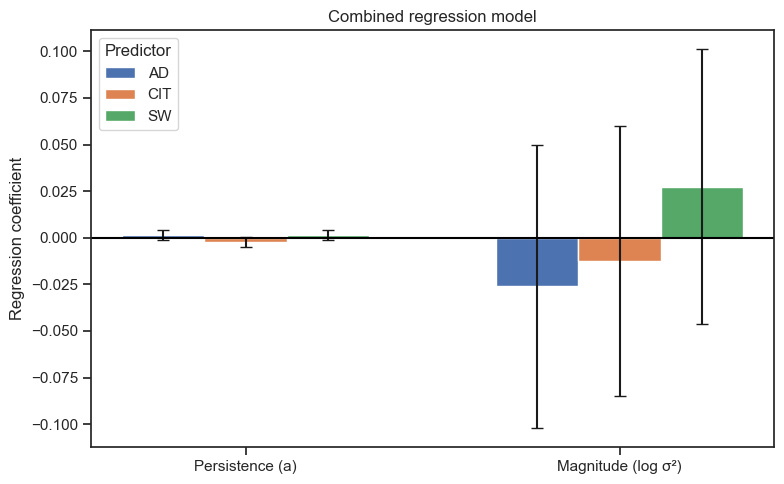

In [25]:
predictors = ["AD","CIT","SW"]
outcomes = ["Persistence (a)","Magnitude (log σ²)"]

x = np.arange(len(outcomes))
width = 0.22
offsets = [-width,0,width]

fig, ax = plt.subplots(figsize=(8,5))

for i,pred in enumerate(predictors):
    
    sub = combined_plot_df[combined_plot_df["predictor"]==pred]
    sub = sub.set_index("outcome").loc[outcomes].reset_index()
    
    betas = sub["beta"].values
    ci_low = sub["ci_low"].values
    ci_high = sub["ci_high"].values
    
    yerr = np.vstack([betas-ci_low,ci_high-betas])
    
    ax.bar(
        x+offsets[i],
        betas,
        width=width,
        yerr=yerr,
        capsize=4,
        label=pred
    )
    
    for j,row in sub.iterrows():
        
        if row["p"] < 0.05:
            
            ax.text(
                x[j]+offsets[i],
                row["ci_low"]-0.03,
                "*",
                ha="center",
                va="top",
                fontsize=16
            )

ax.axhline(0,color="black")

ax.set_xticks(x)
ax.set_xticklabels(outcomes)

ax.set_ylabel("Regression coefficient")
ax.set_title("Combined regression model")

ax.legend(title="Predictor")

plt.tight_layout()
plt.show()